In [1]:
import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset
import os
import torch
from torch.utils.data import Dataset
import torchvision
import torchvision.transforms as transforms
import pandas as pd
from vit import ViTDecoder_v2 as vit
from PIL import Image
import math as math
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# Custom Padding Transformer (FIX THIS)
class load_csv_as_image:
    def __call__(self, path):
        df = pd.read_csv(path, header=None)
        data = df.values  # or use np.loadtxt for speed
        rows, cols = df.shape
        return torch.tensor(data).reshape((rows,cols)).float()

class PadToSize:
    def __init__(self, target):
        self.target = target

    def __call__(self, img):
        # Calculate padding sizes

        h, w = img.shape
        target_w, target_h = self.target

        pad_w = max(0, target_w - w)
        pad_h = max(0, target_h - h)

        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        pad_top = pad_h // 2
        pad_bot = pad_h - pad_top

        padding = (pad_left, pad_top, pad_right, pad_bot)
        img1 = transforms.functional.pad(img, padding, fill=0, padding_mode='reflect')
        return img1
        
class ConvertToFloat32(object):
    def __call__(self, tensor):
        return tensor.to(torch.float32)

class AddChannelDim:
    def __call__(self, x):
        return x.unsqueeze(0)  # Adds channel at dim 0
    
class normalize_min_max():
    def __init__(self, min_val, max_val):
        self.min_val = min_val
        self.max_val = max_val

    def __call__(self, x):
        return (x - self.min_val) / (self.max_val - self.min_val + 1e-8)

In [22]:
target_size = (930, 930)
pipeline= transforms.Compose([
    #transforms.ToTensor(),  # Convert image to tensor
    load_csv_as_image(),
    # transforms.Lambda(lambda x: x[:3]),
    PadToSize(target_size),  # Pad the image to the target size
    ConvertToFloat32(),
    AddChannelDim()
    #transforms.ToPILImage(), 
])

current maxs:
9.010990000000002e-06

current mins:
0.0

eff_dist maxs:
61.3528

eff_dist mins:
0.0

pdn_density maxs:
3.0

pdn_density mins:
0.0

ir_drop maxs:
0.00609974

ir_drop mins:
6.58885e-05

In [23]:
class StackedImagesDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_files = sorted(os.listdir(image_dir))  # Sorted to align image order
        self.label_files = sorted(os.listdir(label_dir))  # Assuming labels have the same order
        self.transform = transform
        self.current_transform = transforms.Compose([
            normalize_min_max(min_val=0, max_val=9.010990000000002e-06)
            ])
        self.eff_dist_transform = transforms.Compose([
            normalize_min_max(min_val=0, max_val=61.3528)  # Normalize
            ])
        self.pdn_density_transform = transforms.Compose([
            normalize_min_max(min_val=0, max_val=3)   # Normalize
            ])
        self.ir_drop_transform = transforms.Compose([
            normalize_min_max(min_val=6.58885e-05, max_val=0.00609974)   # Normalize
            ])

    
    def __len__(self):
        return len(self.label_files) # based off of the label amount
    
    def __getitem__(self, idx):
        # Get 3 consecutive images for stacking (you could choose any other strategy here)
        names = []
        stacked_images = []

        img1_path = os.path.join(self.image_dir, self.image_files[3*idx])
        img2_path = os.path.join(self.image_dir, self.image_files[3*idx+1])
        img3_path = os.path.join(self.image_dir, self.image_files[3*idx+2])
        
        # Load images
        img1 = self.transform(img1_path)
        img2 = self.transform(img2_path)
        img3 = self.transform(img3_path)
        # if self.transform:
        img1 = self.current_transform(img1)
        img2 = self.eff_dist_transform(img2)
        img3 = self.pdn_density_transform(img3)

        # Stack the 3 images into a list for separate encoding
        stacked_images.append(img1)
        stacked_images.append(img2)
        stacked_images.append(img3)

        # Load corresponding label image
        label_path = os.path.join(self.label_dir, self.label_files[idx])  # Label corresponding to last image in stack
        label = self.transform(label_path)
        # if self.transform:
        label = self.ir_drop_transform(label)
        
        names.append(self.image_files[3*idx])
        names.append(self.image_files[3*idx+1])
        names.append(self.image_files[3*idx+2])
        names.append(self.label_files[idx])

        return stacked_images, label, names #, idx, names

In [24]:
image_dataset = StackedImagesDataset(image_dir="/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/all_csvs/inp", label_dir= "/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/all_csvs/ir_drop", transform=pipeline)

In [25]:
for image, label, names in image_dataset:
    # print(image[0].size()[1])
    # print(image[1].size()[1])
    # print(image[2].size()[1])
    # print(label.size()[1])
    #print(names)
    if image[0].size()[1] != 930 and image[1].size()[1] != 930 and image[2].size()[1] != 930 and label.size()[1] != 930:
        print(names[0])
        print(image[0].size())
        print(image[1].size())
        print(image[2].size())
        print(label.size())

In [26]:
train_dataset, test_dataset = torch.utils.data.random_split(image_dataset, [0.75, 0.25])

In [27]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [28]:
model = vit(image_size = (930,930), patch_size = (15,15), dim = 768, depth = 1, heads = 4, mlp_dim = 10, channels=1, out_channels=1) 

In [29]:
criterion = nn.L1Loss()  # For multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Step 4: Training Loop
epochs = 10  # Number of epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0

    for batch_idx, (inputs, labels, names) in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch + 1}", ncols=100)):
        labels = labels.to(device)
        new_inp = []
        for inp in inputs:
            new_inp.append(inp.to(device))

        optimizer.zero_grad()  # Zero the gradients before the backward pass
        # print(inputs.size())
        outputs = model(new_inp, names)  # Forward pass
        # print(outputs.size())
        # print(labels.size())
        loss = criterion(outputs, labels)  # Calculate the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Optimize the model

        running_loss += loss.item()

    # Print statistics for the current epoch
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss: {running_loss/len(train_dataloader):.6f}")

    # Step 5: Evaluate on Test Data
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    with torch.no_grad():  # No need to track gradients during evaluation
        for batch_idx, (inputs, labels, names) in enumerate(tqdm(test_dataloader, desc=f"Testing Epoch {epoch + 1}", ncols=100)):
            labels = labels.to(device)
            new_inp = []
            for inp in inputs:
                new_inp.append(inp.to(device))
                
            outputs = model(new_inp, names)
            loss = criterion(outputs, labels)  # Calculate the loss
            running_loss += loss.item()


    print(f"Test Loss: {running_loss/len(test_dataloader):.6f}")
    print("-" * 50)

print("Training Finished!")

Epoch 1: 100%|██████████████████████████████████████████████████████| 46/46 [14:38<00:00, 19.10s/it]


Epoch 1/10
Loss: 0.151191


Testing Epoch 1: 100%|████████████████████████████████████████████| 152/152 [02:30<00:00,  1.01it/s]


Test Loss: 0.063997
--------------------------------------------------


Epoch 2: 100%|██████████████████████████████████████████████████████| 46/46 [14:29<00:00, 18.90s/it]


...

Test Loss: 0.047355
--------------------------------------------------


Epoch 10: 100%|█████████████████████████████████████████████████████| 46/46 [14:15<00:00, 18.60s/it]


Epoch 10/10
Loss: 0.042549


Testing Epoch 10: 100%|███████████████████████████████████████████| 152/152 [02:14<00:00,  1.13it/s]

Test Loss: 0.047647
--------------------------------------------------
Training Finished!


In [31]:
eval_dataset = StackedImagesDataset(image_dir="/home/bqtx/Documents/VLSI/ir_drop_ml/EvaluationData/evaluation_inputs", label_dir= "/home/bqtx/Documents/VLSI/ir_drop_ml/EvaluationData/evaluation_ir_drop", transform=pipeline)
eval_dataloader = DataLoader(eval_dataset, batch_size=1, shuffle=False)

In [38]:
model.eval()  # Set the model to evaluation mode
running_loss = 0.0
first = 0
with torch.no_grad():  # No need to track gradients during evaluation
    for batch_idx, (inputs, labels, names) in enumerate(tqdm(eval_dataloader, desc=f"Testing Epoch {epoch + 1}", ncols=100)):
        labels = labels.to(device)
        
        new_inp = []
        for inp in inputs:
            new_inp.append(inp.to(device))
        outputs = model(inputs, names)
        loss = criterion(outputs, labels)  # Calculate the loss
        running_loss += loss.item()
        # print(names)
        #if first == 0:
        label_img = labels
        # print(outputs.size())
        saved_img = torch.reshape(outputs, (1,930,930))
        label_img = torch.reshape(label_img, (1,930,930))
        # print(saved_img)
        #plt.imshow(saved_img.numpy()[0], cmap='viridis')
        print(names[0])
        image = transforms.ToPILImage()(saved_img)
        plt.imsave("new_photos/eval_csv-augment"+names[3][0].split(".")[0]+".png", saved_img.numpy()[0], cmap='viridis')
        plt.imsave("label_ir_drop/"+names[3][0].split(".")[0]+".png", label_img.numpy()[0], cmap='viridis')
        #first += 1


print(f"Test Loss: {running_loss/len(eval_dataloader):.6f}")
print("-" * 50)

Testing Epoch 10:   0%|                                                      | 0/10 [00:00<?, ?it/s]

('10_current_map.csv',)


Testing Epoch 10:  10%|████▌                                         | 1/10 [00:01<00:12,  1.35s/it]

('13_current_map.csv',)


Testing Epoch 10:  20%|█████████▏                                    | 2/10 [00:02<00:09,  1.24s/it]

...

('8_current_map.csv',)


Testing Epoch 10:  90%|█████████████████████████████████████████▍    | 9/10 [00:11<00:01,  1.24s/it]

('9_current_map.csv',)


Testing Epoch 10: 100%|█████████████████████████████████████████████| 10/10 [00:12<00:00,  1.26s/it]

Test Loss: 0.149092
--------------------------------------------------


In [35]:
# Ensure same shape
label_img = torch.reshape(label_img, (1,930,930))
print(saved_img.shape)
print(label_img.shape)
assert saved_img.shape == label_img.shape, "Images must be the same size and shape."

# Compute MSE
mse = np.mean((saved_img.numpy() - label_img.numpy()) ** 2)
print(f"MSE: {mse}")

torch.Size([1, 930, 930])
torch.Size([1, 930, 930])
MSE: 0.010280671529471874


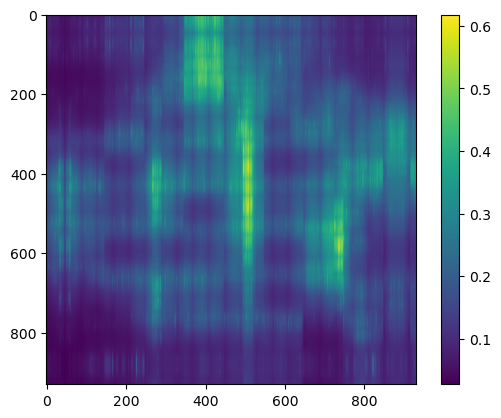

In [36]:
plt.imshow(label_img.numpy()[0], cmap='viridis')
plt.colorbar()

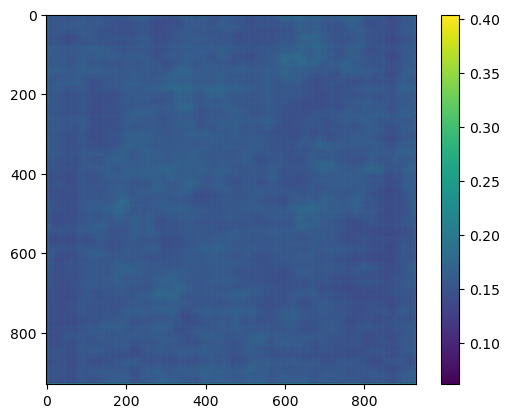

In [18]:
plt.imshow(saved_img.numpy()[0], cmap='viridis')
plt.colorbar()

In [19]:
print(torch.max(saved_img))
print(torch.max(label_img))
print(torch.min(saved_img))
print(torch.min(label_img))
print(torch.mean(saved_img))
print(torch.mean(label_img))
print(torch.std(saved_img))
print(torch.std(label_img))

tensor(0.4040)
tensor(0.1942)
tensor(0.0615)
tensor(0.0392)
tensor(0.1556)
tensor(0.1046)
tensor(0.0145)
tensor(0.0230)


In [20]:
df = pd.DataFrame(saved_img.numpy()[0])
print(df)

          0         1         2         3         4         5         6    \
0    0.233091  0.336881  0.208654  0.239931  0.145453  0.283669  0.178079   
1    0.304419  0.403962  0.189055  0.253864  0.274662  0.258092  0.204158   
2    0.234067  0.216018  0.125993  0.143083  0.192200  0.159335  0.143114   
3    0.267374  0.296292  0.125531  0.130370  0.149801  0.155187  0.143217   
4    0.204204  0.201702  0.143688  0.144194  0.166650  0.163092  0.175997   
..        ...       ...       ...       ...       ...       ...       ...   
925  0.272916  0.324889  0.160633  0.171135  0.179330  0.168273  0.147148   
926  0.220248  0.220281  0.117639  0.110138  0.100161  0.123811  0.114934   
927  0.274393  0.265999  0.113697  0.122354  0.130534  0.140060  0.131370   
928  0.388090  0.270582  0.205742  0.199470  0.282247  0.172557  0.242488   
929  0.356133  0.366536  0.241086  0.193132  0.208746  0.235513  0.248926   

          7         8         9    ...       920       921       922  \
0  

In [ ]:
df = pd.read_csv("/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/csv-files/ir_drop_csvs/73_ir_drop.csv")
print(df)

     1.024659999999999937e-03  1.019249999999999974e-03  \
0                    0.001025                  0.001019   
1                    0.001031                  0.001026   
2                    0.001038                  0.001031   
3                    0.001045                  0.001039   
4                    0.001051                  0.001044   
..                        ...                       ...   
791                  0.000684                  0.000679   
792                  0.000685                  0.000679   
793                  0.000685                  0.000682   
794                  0.000686                  0.000681   
795                  0.000686                  0.000681   

     1.023620000000000042e-03  1.046889999999999973e-03  \
0                    0.001024                  0.001047   
1                    0.001030                  0.001055   
2                    0.001037                  0.001063   
3                    0.001043                  0.001067

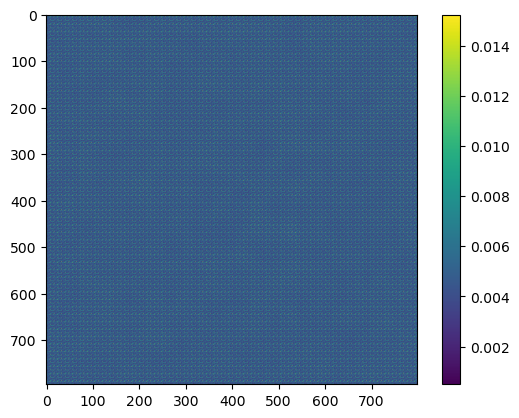

In [ ]:
def center_crop(img, crop_height, crop_width):
    h, w = img.shape[-2:]  # supports [H, W] or [C, H, W]
    top = (h - crop_height) // 2
    left = (w - crop_width) // 2
    if img.ndim == 3:
        return img[:, top:top + crop_height, left:left + crop_width]  # [C, H, W]
    else:
        return img[top:top + crop_height, left:left + crop_width]  # [H, W]

cropped1 = center_crop(saved_img[0], 796, 798)
plt.imshow(cropped1, cmap='viridis')
plt.colorbar()

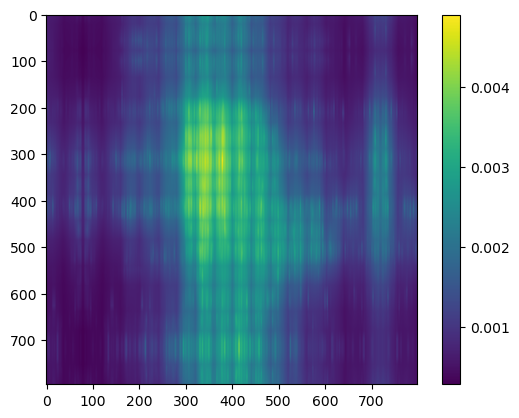

In [ ]:
cropped2 = center_crop(label_img[0], 796, 798)
plt.imshow(cropped2, cmap='viridis')
plt.colorbar()

In [ ]:
test_dataloader = DataLoader(test_dataset, batch_size=5, shuffle=False)
model.eval()  # Set the model to evaluation mode
running_loss = 0.0
with torch.no_grad():  # No need to track gradients during evaluation
    for batch_idx, (inputs, labels, names) in enumerate(tqdm(test_dataloader, desc=f"Testing Epoch {epoch + 1}", ncols=100)):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)  # Calculate the loss
        running_loss += loss.item()
        print(names)


print(f"Test Loss: {running_loss/len(test_dataloader):.4f}")
print("-" * 50)

In [ ]:
maxs = [-999,-999,-999,-999]
mins = [999,999,999,999]
index = 0
directory = os.listdir("/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/csv-files/input_csvs")

temp_transform = transforms.Compose([
    transforms.ToTensor()  # Converts to tensor and scales values to [0, 1]
])

for file in directory:
    if "current" in file:
        index = 0
    elif "eff_dist" in file:
        index = 1
    elif "pdn_density" in file:
        index = 2
    image_path = os.path.join("/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/csv-files/input_csvs", file)
        
    # Calculate the mean and std for the current image
    maxs[index] = max(maxs[index], pd.read_csv(image_path).values.max())   # Max for each channel (R, G, B)
    mins[index] = min(mins[index], pd.read_csv(image_path).values.min())  # Std for each channel (R, G, B)

In [ ]:
directory = os.listdir("/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/csv-files/ir_drop_csvs")
for file in directory:
    image_path = os.path.join("/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/csv-files/ir_drop_csvs", file)
        
    # Open the image
    image = os.path.join("/home/bqtx/Documents/VLSI/ir_drop_ml/training_data/csv-files/ir_drop_csvs", file)
        
    # Calculate the mean and std for the current image
    maxs[3] = max(maxs[3], pd.read_csv(image_path).values.max())   # Max for each channel (R, G, B)
    mins[3] = min(mins[3], pd.read_csv(image_path).values.min())  # Std for each channel (R, G, B)

In [ ]:
print("current maxs:")
print(maxs[0])
print("current mins:")
print(mins[0])
print("eff_dist maxs:")
print(maxs[1])
print("eff_dist mins:")
print(mins[1])
print("pdn_density maxs:")
print(maxs[2])
print("pdn_density mins:")
print(mins[2])
print("ir_drop maxs:")
print(maxs[3])
print("ir_drop mins:")
print(mins[3])

current maxs:
9.010990000000002e-06
current mins:
0.0
eff_dist maxs:
61.3528
eff_dist mins:
0.0
pdn_density maxs:
3.0
pdn_density mins:
0.0
ir_drop maxs:
0.00609974
ir_drop mins:
6.58885e-05


In [22]:
torch.save(model.state_dict(), "/home/bqtx/Documents/VLSI/ir_drop_ml/model/0409_weights.pth")

In [5]:
model2 = vit(image_size = (930,930), patch_size = (15,15), dim = 768, depth = 1, heads = 4, mlp_dim = 10, channels=1, out_channels=1)

model2.load_state_dict(torch.load("/home/bqtx/Documents/VLSI/ir_drop_ml/model/0409_weights.pth", weights_only=True))
model2.eval()

ViTDecoder_v2(
  (to_patch_embedding_X): Sequential(
    (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=15, p2=15)
    (1): LayerNorm((225,), eps=1e-05, elementwise_affine=True)
    (2): Linear(in_features=225, out_features=768, bias=True)
    (3): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (dropout_X): Dropout(p=0.0, inplace=False)
  (transformer_X): Transformer(
    (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (layers): ModuleList(
      (0): ModuleList(
        (0): Attention(
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attend): Softmax(dim=-1)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_qkv): Linear(in_features=768, out_features=768, bias=False)
          (to_out): Sequential(
            (0): Linear(in_features=256, out_features=768, bias=True)
            (1): Dropout(p=0.0, inplace=False)
          )
        )
        (1): FeedForward(
          (net): Sequential(
     

In [25]:
eval_dataset = StackedImagesDataset(image_dir="/home/bqtx/Documents/VLSI/ir_drop_ml/EvaluationData/evaluation_inputs", label_dir= "/home/bqtx/Documents/VLSI/ir_drop_ml/EvaluationData/evaluation_ir_drop", transform=pipeline)

In [26]:
eval_dataloader = DataLoader(eval_dataset, batch_size=1, shuffle=False)

In [30]:
model2.eval()  # Set the model to evaluation mode
criterion = nn.L1Loss()  # For multi-class classification
optimizer = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-5)
running_loss = 0.0
first = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with torch.no_grad():  # No need to track gradients during evaluation
    for batch_idx, (inputs, labels, names) in enumerate(tqdm(eval_dataloader, desc=f"Testing Epoch", ncols=100)):
        labels = labels.to(device)
        
        new_inp = []
        for inp in inputs:
            new_inp.append(inp.to(device))
        outputs = model2(inputs, names)
        loss = criterion(outputs, labels)  # Calculate the loss
        running_loss += loss.item()
        # print(names)
        #if first == 0:
        label_img = labels
        # print(outputs.size())
        saved_img = torch.reshape(outputs, (1,930,930))
        # print(saved_img)
        #plt.imshow(saved_img.numpy()[0], cmap='viridis')
        print(names[0])
        image = transforms.ToPILImage()(saved_img)
        plt.imsave("model_output_photos/eval_csv-triencoder_"+names[3][0].split(".")[0]+".png", saved_img.numpy()[0], cmap='viridis')
        plt.imsave("label_ir_drop/"+names[3][0].split(".")[0]+".png", label_img.numpy(), cmap='viridis')
        #first += 1


print(f"Test Loss: {running_loss/len(eval_dataloader):.6f}")
print("-" * 50)

Testing Epoch:   0%|                                                         | 0/10 [00:00<?, ?it/s]

('10_current_map.csv',)


Testing Epoch:  10%|████▉                                            | 1/10 [00:01<00:11,  1.26s/it]

('13_current_map.csv',)


Testing Epoch:  20%|█████████▊                                       | 2/10 [00:02<00:09,  1.15s/it]

...

('8_current_map.csv',)


Testing Epoch:  90%|████████████████████████████████████████████     | 9/10 [00:10<00:01,  1.17s/it]

('9_current_map.csv',)


Testing Epoch: 100%|████████████████████████████████████████████████| 10/10 [00:11<00:00,  1.18s/it]

Test Loss: 0.157972
--------------------------------------------------
